# Artigo 0009 - Saída Estruturada com LLMs Locais

Compare JSON parseável, conformidade com schema e acerto de negócio.
Valide sempre no consumidor: timeout e truncamento ainda podem interromper a saída.
O runner consolida até duas tentativas por tarefa; tempo e tokens devem ser lidos
com essa política em mente. As métricas desta execução não sobrescrevem os dados
históricos durante a revisão (o laboratório é executado em uma cópia isolada).


In [1]:
get_ipython().run_line_magic("matplotlib", "inline")
from pathlib import Path
import sys
import json
import time
import urllib.request
import jsonschema
import pandas as pd
import matplotlib.pyplot as plt

# Localização dinâmica da raiz do artigo
candidate_dirs = [
    Path.cwd(),
    Path.cwd() / "0009_saida_estruturada",
    Path.cwd().parent,
    Path.cwd().parent / "0009_saida_estruturada",
]
ARTICLE_ROOT = next((p.resolve() for p in candidate_dirs if (p / "src" / "structured_lab.py").exists()), Path.cwd())
if str(ARTICLE_ROOT) not in sys.path:
    sys.path.insert(0, str(ARTICLE_ROOT))

from src.structured_lab import (
    DEFAULT_BASE_URL,
    DEFAULT_CHAT_MODELS,
    PLANNER_SCHEMA,
    EXTRACAO_SCHEMA,
    ROTAS_SCHEMA,
    check_server,
    gerar,
    avaliar,
    run_lab,
)
print(f"Artigo carregado em: {ARTICLE_ROOT}")

Artigo carregado em: /private/tmp/pathbit-review/notebooks/0009_saida_estruturada


## 1. Healthcheck do Servidor Ollama

Verificamos se o Ollama está ativo na porta local `11434` e se os modelos compactos (`qwen2.5:0.5b`, `qwen2.5:1.5b`, `llama3.2:1b`) estão carregados no volume.

In [2]:
server = check_server(DEFAULT_BASE_URL)
print(f"✓ Ollama versão {server['version']} ativo em {DEFAULT_BASE_URL}")
print(f"✓ Modelos disponíveis: {', '.join(server['models'])}")

✓ Ollama versão 0.35.1 ativo em http://localhost:11434
✓ Modelos disponíveis: llama3.2:1b, qwen2.5:1.5b, nomic-embed-text:latest, qwen2.5:0.5b


## 2. Teste Direto: O Mesmo Prompt nos Três Níveis de Contrato

Vamos submeter uma tarefa de extração de devolução a um modelo ultraleve (`qwen2.5:0.5b`) em três modalidades:
- **Modo Livre:** Prompt pedindo JSON.
- **Modo JSON:** Parâmetro `format: 'json'`.
- **Modo Schema:** Parâmetro `format: EXTRACAO_SCHEMA`.

In [3]:
prompt_teste = "Extraia o produto e o prazo da frase: 'quero devolver um televisor comprado ha 10 dias'."

print("--- NÍVEL 1: Modo Livre (Prompt Only) ---")
res_livre = gerar(DEFAULT_BASE_URL, "qwen2.5:0.5b", prompt_teste, "livre", None, 0.0)
print("Resposta:", res_livre["resposta"])
parse_ok, schema_ok, _ = avaliar(res_livre["resposta"], EXTRACAO_SCHEMA)
print(f"Status: parse_ok={parse_ok}, schema_ok={schema_ok}")

print("\n--- NÍVEL 2: Modo JSON (format='json') ---")
res_json = gerar(DEFAULT_BASE_URL, "qwen2.5:0.5b", prompt_teste, "json", None, 0.0)
print("Resposta:", res_json["resposta"])
parse_ok, schema_ok, _ = avaliar(res_json["resposta"], EXTRACAO_SCHEMA)
print(f"Status: parse_ok={parse_ok}, schema_ok={schema_ok}")

print("\n--- NÍVEL 3: Modo Schema (format=EXTRACAO_SCHEMA) ---")
res_schema = gerar(DEFAULT_BASE_URL, "qwen2.5:0.5b", prompt_teste, "schema", EXTRACAO_SCHEMA, 0.0)
print("Resposta:", res_schema["resposta"])
parse_ok, schema_ok, _ = avaliar(res_schema["resposta"], EXTRACAO_SCHEMA)
print(f"Status: parse_ok={parse_ok}, schema_ok={schema_ok}")

--- NÍVEL 1: Modo Livre (Prompt Only) ---


Resposta: O produto que você está procurando é um televisor. O prazo de devolução é de 10 dias.
Status: parse_ok=False, schema_ok=False

--- NÍVEL 2: Modo JSON (format='json') ---


Resposta: { "produto": "televisor", "prazo": "10 dias" }
Status: parse_ok=True, schema_ok=False

--- NÍVEL 3: Modo Schema (format=EXTRACAO_SCHEMA) ---


Resposta: { "produto": "televisor", "prazo_dias": 10 }
Status: parse_ok=True, schema_ok=True


## 3. Matriz do Laboratório Automatizado

Executamos a matriz completa de testes cobrindo os modelos `qwen2.5:0.5b`, `qwen2.5:1.5b` e `llama3.2:1b` sobre três tarefas corporativas (`planner`, `extracao`, `roteamento`).

In [4]:
# Carregamos os resultados medidos pelo laboratório ou executamos uma rodada rápida
csv_resultados = ARTICLE_ROOT / "data" / "structured_resultados.csv"
csv_resumo = ARTICLE_ROOT / "data" / "structured_resumo.csv"

if csv_resumo.exists():
    resumo_df = pd.read_csv(csv_resumo)
    print("Resultados carregados de data/structured_resumo.csv:")
    display(resumo_df)
else:
    print("Executando laboratório para gerar métricas...")
    _, resumo_df, _ = run_lab(DEFAULT_BASE_URL, ["qwen2.5:0.5b", "qwen2.5:1.5b"], repeat=1)
    display(resumo_df)

Resultados carregados de data/structured_resumo.csv:


,modo,parse_ok_pct,schema_ok_pct,semantico_ok_pct,recuperado_pct,total_medio_ms,tokens_medios,chamadas
0,json,88.9,0.0,0.0,0.0,1158.3,39.2,18
1,livre,0.0,0.0,0.0,0.0,3007.7,87.2,18
2,schema,100.0,100.0,44.4,NaN,400.5,22.7,18


## 4. Visualização Gráfica do Desempenho dos Modos

Comparamos a evolução da conformidade de schema e a latência de execução.

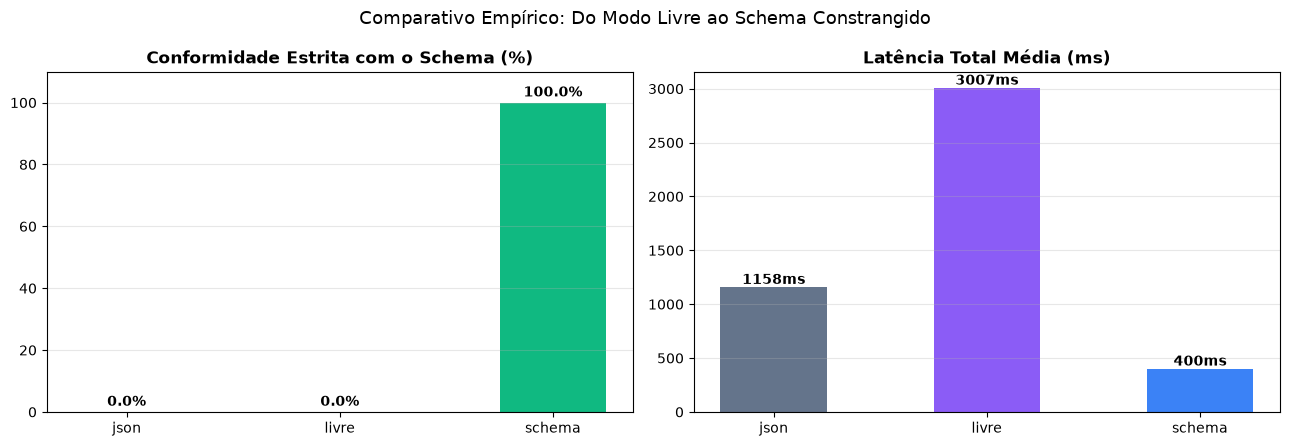

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# Gráfico 1: Conformidade com o Schema
ax1.bar(resumo_df["modo"], resumo_df["schema_ok_pct"], color=["#ef4444", "#f59e0b", "#10b981"], width=0.5)
ax1.set_title("Conformidade Estrita com o Schema (%)", fontsize=12, fontweight="bold")
ax1.set_ylim(0, 110)
for i, v in enumerate(resumo_df["schema_ok_pct"]):
    ax1.text(i, v + 2, f"{v}%", ha="center", fontweight="bold")
ax1.grid(axis="y", alpha=0.3)

# Gráfico 2: Latência Média por Modo
ax2.bar(resumo_df["modo"], resumo_df["total_medio_ms"], color=["#64748b", "#8b5cf6", "#3b82f6"], width=0.5)
ax2.set_title("Latência Total Média (ms)", fontsize=12, fontweight="bold")
for i, v in enumerate(resumo_df["total_medio_ms"]):
    ax2.text(i, v + 30, f"{int(v)}ms", ha="center", fontweight="bold")
ax2.grid(axis="y", alpha=0.3)

plt.suptitle("Comparativo Empírico: Do Modo Livre ao Schema Constrangido", fontsize=13)
plt.tight_layout()
plt.show()

## 5. Padrão de Integração em Produção com Pydantic

Como usar classes Pydantic para tipagem estrita no backend sem escrever JSON Schema manualmente.

In [6]:
from pydantic import BaseModel, Field
from typing import Literal

class DecisaoRoteamento(BaseModel):
    rota: Literal["buscar_politica", "criar_ticket", "resposta_direta"]
    urgencia: Literal["baixa", "media", "alta"]
    justificativa: str = Field(description="Motivo resumido da decisão")

# Extração automática do schema para passar ao Ollama
schema_pydantic = DecisaoRoteamento.model_json_schema()
print("Schema Pydantic gerado automaticamente:")
print(json.dumps(schema_pydantic, indent=2))

# Invocando com o schema
resultado = gerar(
    DEFAULT_BASE_URL,
    "qwen2.5:0.5b",
    "Classifique a mensagem: 'servidor caiu e banco de dados nao responde'.",
    "schema",
    schema_pydantic,
    0.0
)

# Deserialização direta em objeto tipado (sem try/catch para KeyError)
decisao = DecisaoRoteamento.model_validate_json(resultado["resposta"])
print(f"\n✓ Objeto Pydantic instanciado com sucesso!")
print(f"  Rota: {decisao.rota}")
print(f"  Urgência: {decisao.urgencia}")
print(f"  Justificativa: {decisao.justificativa}")

Schema Pydantic gerado automaticamente:
{
  "properties": {
    "rota": {
      "enum": [
        "buscar_politica",
        "criar_ticket",
        "resposta_direta"
      ],
      "title": "Rota",
      "type": "string"
    },
    "urgencia": {
      "enum": [
        "baixa",
        "media",
        "alta"
      ],
      "title": "Urgencia",
      "type": "string"
    },
    "justificativa": {
      "description": "Motivo resumido da decis\u00e3o",
      "title": "Justificativa",
      "type": "string"
    }
  },
  "required": [
    "rota",
    "urgencia",
    "justificativa"
  ],
  "title": "DecisaoRoteamento",
  "type": "object"
}



✓ Objeto Pydantic instanciado com sucesso!
  Rota: criar_ticket
  Urgência: media
  Justificativa: servidor caiu e banco de dados não responde


## 6. Baseline de roteamento por embeddings, sem geração

`benchmark_system_one` é o nome histórico da função, não a implementação de
Jev/Laya. O código calcula `nomic-embed-text` e escolhe a maior similaridade entre
três rótulos. Não mede uma cabeça de decisão comercial nem confiança calibrada.
Uma passada de encoder não tem custo O(1) em relação ao tamanho do texto.


In [7]:
from src.structured_lab import benchmark_system_one

print("Executando benchmark do decisor System 1 (passada única em CPU local)...")
sys1_results = benchmark_system_one(DEFAULT_BASE_URL, repeat=3)

print("\nResultado Empírico do Modelo System 1:")
for k, v in sys1_results.items():
    print(f"  • {k}: {v}")

Executando benchmark do decisor System 1 (passada única em CPU local)...



Resultado Empírico do Modelo System 1:
  • paradigma: Roteador por embeddings nomic-embed-text e similaridade de cosseno
  • frameworks_referencia: ['Ollama / nomic-embed-text']
  • chamadas_avaliadas: 9
  • acuracia_pct: 100.0
  • latencia_media_ms: 20.93
  • latencia_p50_ms: 19.21
  • latencia_p95_ms: 35.43
  • tokens_gerados: 0
  • conformidade_schema_pct: 100.0


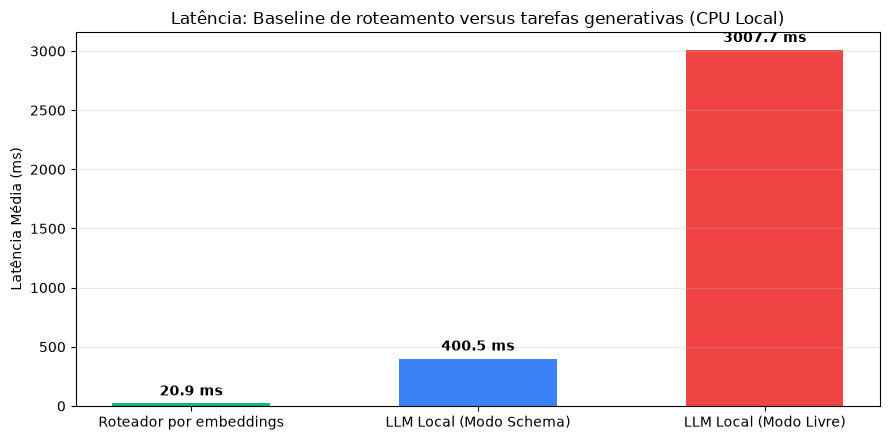

In [8]:
# Comparativo visual de latência: System 1 vs System 2 (valores medidos em data/)
lat_livre = resumo_df.loc[resumo_df["modo"] == "livre", "total_medio_ms"].iloc[0]
lat_schema = resumo_df.loc[resumo_df["modo"] == "schema", "total_medio_ms"].iloc[0]

modelos_nomes = ["Roteador por embeddings", "LLM Local (Modo Schema)", "LLM Local (Modo Livre)"]
latencias = [sys1_results["latencia_media_ms"], lat_schema, lat_livre]
cores = ["#10b981", "#3b82f6", "#ef4444"]

plt.figure(figsize=(9, 4.5))
bars = plt.bar(modelos_nomes, latencias, color=cores, width=0.55)
plt.ylabel("Latência Média (ms)")
plt.title("Latência: Baseline de roteamento versus tarefas generativas (CPU Local)")
plt.grid(axis="y", alpha=0.3)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 40, f"{yval:.1f} ms", ha="center", va="bottom", fontweight="bold")

plt.tight_layout()
plt.show()


## 7. Próximo passo

Com saída validada e limites semânticos explícitos, conectamos ferramentas ao
[MCP local](../../0010_mcp_local/article/ARTICLE.md). Contrato não é sandbox nem
garantia de decisão correta.
